Import some useful libraries

In [5]:
from LQR import *
from DGM import *
from FNN import *
from PDE_Solve_dgm import *
from Policy_Iteration import *

Define LQR parameters

In [6]:
H = np.array([[1.0, 0.5], [0.0, 1.0]])
M = np.array([[1.0, 0.0], [0.0, 1.0]])
C = np.array([[1.0, 0.0], [0.0, 1.0]])
D = np.array([[1.0, 0.0], [0.0, 1.0]])
R = np.array([[1.0, 0.0], [0.0, 1.0]])
sigma = np.array([[0.5, 0.0], [0.0, 0.5]])
T = 1.0

lqr = LQR(H, M, C, D, R, sigma, T)

Exercise 1.1 : Solve Riccati ODE and test value function and control

In [7]:
time_grid = np.linspace(0, T, 500)
lqr.Sol_Ricatti(time_grid)

t_test = torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32)
x_test = torch.tensor([[[1.0, 1.0]],[[0.0, 1.0]],[[1.0, 2.0]]],dtype=torch.float32)

v = lqr.Sol_value(t_test, x_test)
a = lqr.control(t_test, x_test)

print("\n Value function v(t, x):")
for i in range(len(t_test)):
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> v={v[i].item():.4f}")

print("\n Optimal control a(t, x):")
for i in range(len(t_test)):
    a_i = a[i].tolist()
    a_str = f"[{a_i[0]:.4f}, {a_i[1]:.4f}]"
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> a={a_str}")


 Value function v(t, x):
t=0.0, x=[1.0, 1.0] -> v=6.2425
t=0.5, x=[0.0, 1.0] -> v=2.2742
t=1.0, x=[1.0, 2.0] -> v=5.0000

 Optimal control a(t, x):
t=0.0, x=[1.0, 1.0] -> a=[-2.6109, -2.7355]
t=0.5, x=[0.0, 1.0] -> a=[-0.2771, -1.9066]
t=1.0, x=[1.0, 2.0] -> a=[-1.0000, -2.0000]


Exercise 1.2: Monte Carlo Error Analysis

Benchmark value v(t,x) = 6.242467
N_steps=    1, mean abs error=1.1112e+01
N_steps=   10, mean abs error=3.8545e-01
N_steps=   50, mean abs error=6.8353e-02
N_steps=  100, mean abs error=3.8027e-02
N_steps=  500, mean abs error=9.9926e-03
N_steps= 1000, mean abs error=4.9026e-03
N_steps= 5000, mean abs error=4.6464e-03
N_samples=    10, mean abs error=2.9838e-01
N_samples=    50, mean abs error=2.8148e-01
N_samples=   100, mean abs error=9.0514e-02
N_samples=   500, mean abs error=1.0339e-01
N_samples=  1000, mean abs error=5.3842e-02
N_samples=  5000, mean abs error=1.7643e-02
N_samples= 10000, mean abs error=2.2031e-02
N_samples= 50000, mean abs error=7.5012e-03
N_samples=100000, mean abs error=6.8227e-03


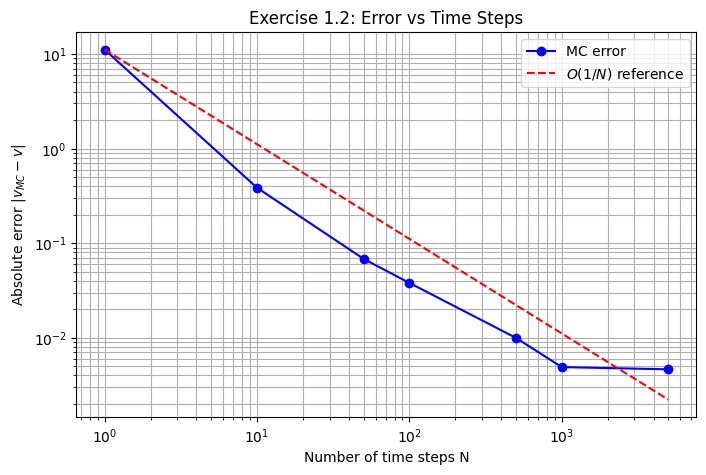

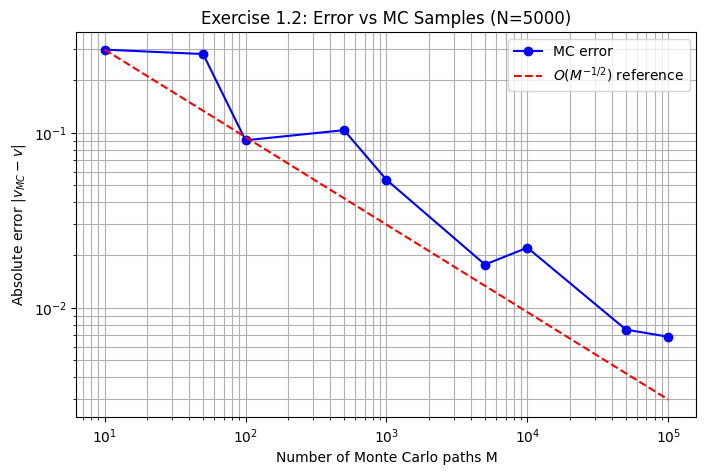

{'v_exact': 6.242466926574707,
 'steps_list': [1, 10, 50, 100, 500, 1000, 5000],
 'errors_steps': [11.11176243752303,
  0.3854542582432405,
  0.06835346777774891,
  0.03802710374309566,
  0.009992557869520979,
  0.004902613983965409,
  0.004646367264106921],
 'samples_list': [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
 'errors_samples': [0.2983848027651378,
  0.2814833370075256,
  0.09051417922179787,
  0.10339132745808718,
  0.05384177483293566,
  0.017642640183798262,
  0.022031346281189988,
  0.007501202933138984,
  0.006822670801457598]}

In [14]:
lqr.error_analysis(
    t=0.0,
    x=np.array([1.0, 1.0]),
    steps_list=[1, 10, 50, 100, 500, 1000, 5000],
    samples_list=[10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
    fixed_paths=100000,
    fixed_steps=5000,
    repetitions=5,
    seed=1234)

Exercise 2.1: Supervised learning of value function

Epoch 0/1000, loss=191.963715
Epoch 100/1000, loss=1.805346
Epoch 200/1000, loss=0.507339
Epoch 300/1000, loss=0.211885
Epoch 400/1000, loss=0.060666
Epoch 500/1000, loss=0.038316
Epoch 600/1000, loss=0.019947
Epoch 700/1000, loss=0.017110
Epoch 800/1000, loss=0.010127
Epoch 900/1000, loss=0.017892


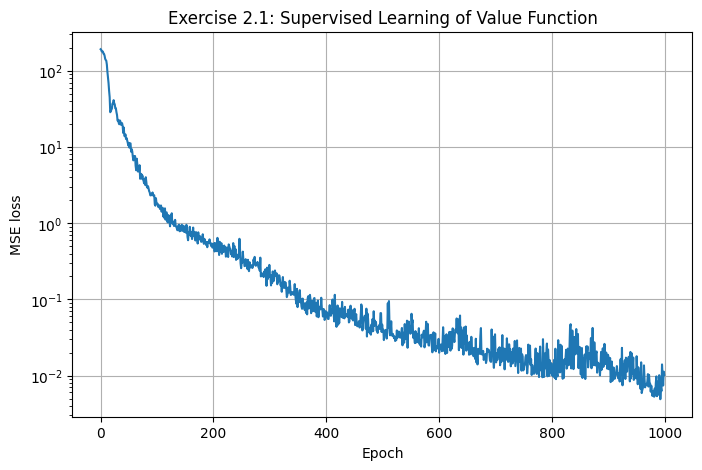

In [9]:
value_net, _ = train_value_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

Exercise 2.2: Supervised learning of control

Epoch 0/1000, loss=10.4374
Epoch 100/1000, loss=0.6072
Epoch 200/1000, loss=0.1192
Epoch 300/1000, loss=0.0567
Epoch 400/1000, loss=0.0505
Epoch 500/1000, loss=0.0407
Epoch 600/1000, loss=0.0373
Epoch 700/1000, loss=0.0357
Epoch 800/1000, loss=0.0304
Epoch 900/1000, loss=0.0208


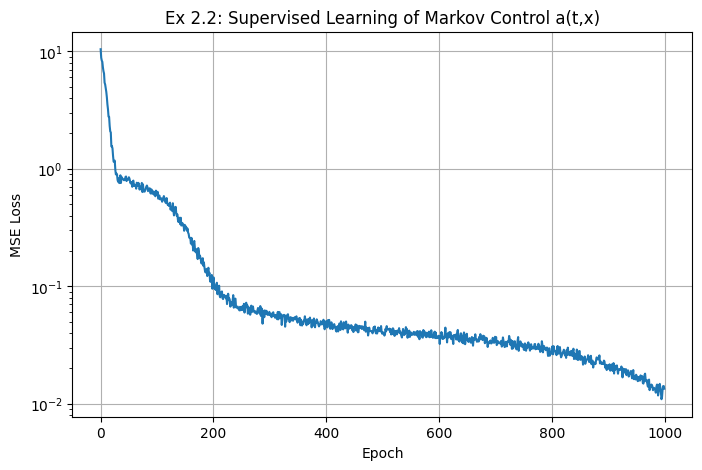

In [10]:
control_net, _ = train_control_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

Extra Test for exercise 2

Exercise 3.1: DGM for the linear PDE

The Monte Carlo benchmark below reuses the Exercise 1.2 simulation routine with constant control alpha=(1,1)^T.

Epoch 0/1000 | total=123.403008 | pde=69.555000 | boundary=53.848007
  -> mean MC benchmark error = 3.7249e+01
Epoch 100/1000 | total=8.183300 | pde=4.105610 | boundary=4.077690
Epoch 200/1000 | total=0.723892 | pde=0.302454 | boundary=0.421438
  -> mean MC benchmark error = 2.0674e+01
Epoch 300/1000 | total=0.471592 | pde=0.356951 | boundary=0.114640
Epoch 400/1000 | total=0.110794 | pde=0.056098 | boundary=0.054696
Epoch 500/1000 | total=0.162245 | pde=0.101466 | boundary=0.060778
  -> mean MC benchmark error = 1.8970e+01
Epoch 600/1000 | total=0.061564 | pde=0.026450 | boundary=0.035114
Epoch 700/1000 | total=0.055264 | pde=0.033219 | boundary=0.022045
  -> mean MC benchmark error = 1.8096e+01
Epoch 800/1000 | total=0.108123 | pde=0.082033 | boundary=0.026090
Epoch 900/1000 | total=0.076001 | pde=0.037452 | boundary=0.038550


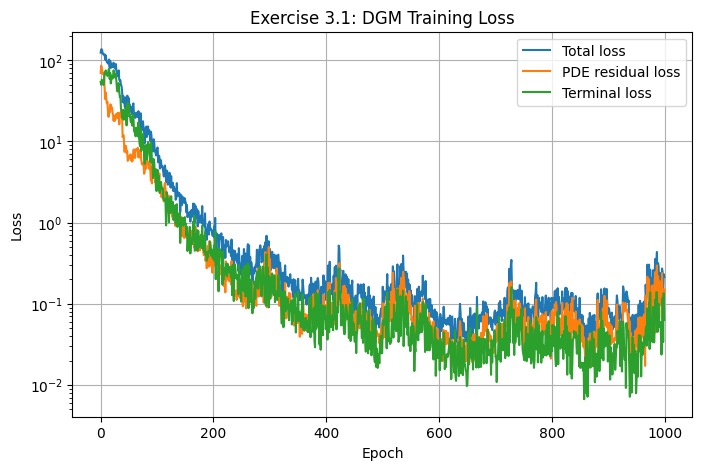

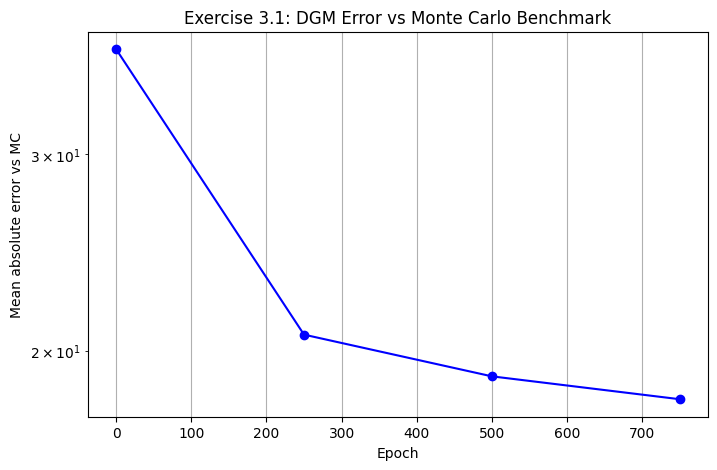

(Net_DGM(
   (input_layer): Sequential(
     (0): Linear(in_features=3, out_features=100, bias=True)
     (1): Tanh()
   )
   (DGM1): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_H): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
   )
   (DGM2): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_f

In [11]:
train_dgm_linear_pde(lqr, n_epochs=1000, batch_size=128, lr=1e-3, eval_every=250)

Exercise 4.1: Policy iteration

Using Exercise 2.1 value network as the initial guess for policy iteration.
Using Exercise 2.2 control network as the initial guess for policy iteration.

Policy iteration 1/5
  [Value] epoch 0/300, loss=0.798379
  [Value] epoch 60/300, loss=5.103897
  [Value] epoch 120/300, loss=1.457664
  [Value] epoch 180/300, loss=0.782126
  [Value] epoch 240/300, loss=0.478015
  [Control] epoch 0/200, Hamiltonian=8.149674
  [Control] epoch 40/200, Hamiltonian=8.363684
  [Control] epoch 80/200, Hamiltonian=7.218628
  [Control] epoch 120/200, Hamiltonian=7.199523
  [Control] epoch 160/200, Hamiltonian=7.266920
  mean |v_pred-v_exact| = 1.6552e-01
  mean ||a_pred-a_exact|| = 1.3830e-01

Policy iteration 2/5
  [Value] epoch 0/300, loss=0.719238
  [Value] epoch 60/300, loss=4.335946
  [Value] epoch 120/300, loss=0.448999
  [Value] epoch 180/300, loss=0.275021
  [Value] epoch 240/300, loss=0.447745
  [Control] epoch 0/200, Hamiltonian=7.125968
  [Control] epoch 40/200, Hamiltonian=7.891955
  [Control] e

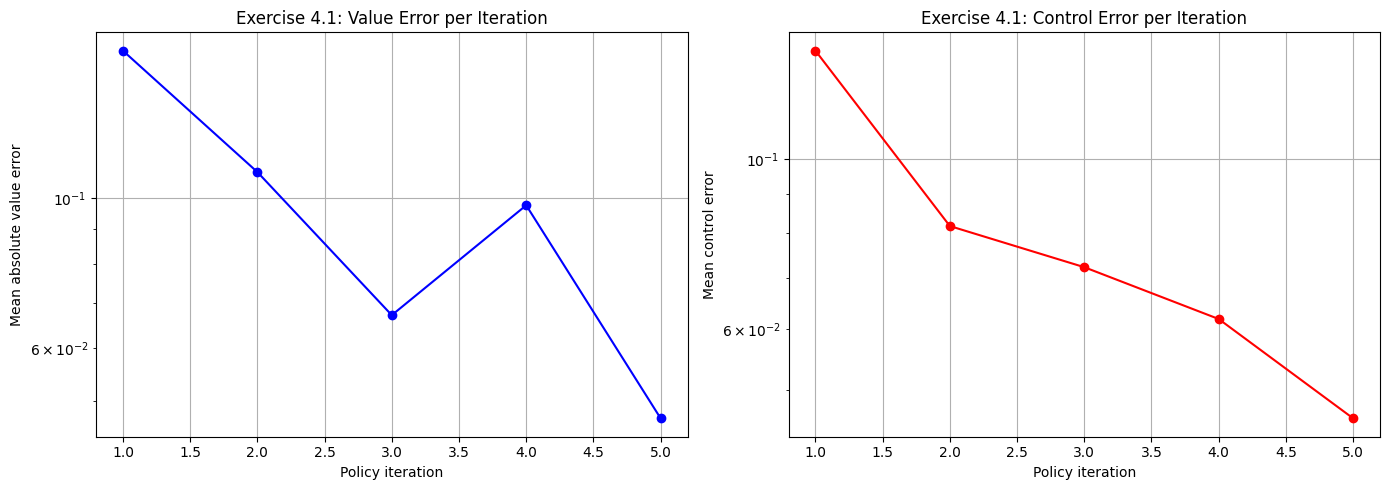

(Net_DGM(
   (input_layer): Sequential(
     (0): Linear(in_features=3, out_features=100, bias=True)
     (1): Tanh()
   )
   (DGM1): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_H): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
   )
   (DGM2): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_f

In [13]:
train_policy_iteration(
        lqr,
        n_iterations=5,
        n_epochs_val=300,
        n_epochs_act=200,
        batch_size=128,
        lr=1e-3,
        initial_value_net=value_net,
        initial_control_net=control_net,
)